<a href="https://colab.research.google.com/github/siojzz/Practical-Statistics-for-Data-Scientists/blob/main/PracticalStatisticsChapter3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 3 - Statistical Experiments and Significance Testing

This notebook contains my code reproduction and notes for Chapter 3 of *Practical Statistics for Data Scientists*.

This chapter focuses on experiments, hypothesis testing, resampling, statistical significance, and methods for comparing groups.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from scipy import stats

## 1. A/B Testing

A/B testing is an experiment that compares two treatments or alternatives.

Usually, one group receives treatment A and another group receives treatment B. The goal is to determine whether the outcomes between the two groups are different.

## 2. Hypothesis Tests

A hypothesis test is used to determine whether an observed difference between groups could be caused by random chance.

The null hypothesis assumes that there is no real difference between the groups.

The alternative hypothesis assumes that there is a real difference.

### 2.1 One-Tailed and Two-Tailed Tests

A one-tailed test checks for a difference in one specific direction.

A two-tailed test checks for differences in both directions.

## 3. Resampling

Resampling means repeatedly drawing samples from observed data.

Two common resampling methods are bootstrap and permutation tests.

A permutation test is commonly used to test whether differences between groups could happen by chance.

In [2]:
!wget -O web_page_data.csv https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/web_page_data.csv

--2026-10-01 07:08:54--  https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/web_page_data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 441 [text/plain]
Saving to: ‘web_page_data.csv’

web_page_data.csv   100%[===================>]     441  --.-KB/s    in 0s      

2026-10-01 07:08:55 (18.7 MB/s) - ‘web_page_data.csv’ saved [441/441]



In [3]:
session_times = pd.read_csv("web_page_data.csv")

session_times.head()

,Page,Time
0,Page A,0.21
1,Page B,2.53
2,Page A,0.35
3,Page B,0.71
4,Page A,0.67


In [4]:
session_times["Time"] = 100 * session_times["Time"]

session_times.head()

,Page,Time
0,Page A,21.0
1,Page B,253.0
2,Page A,35.0
3,Page B,71.0
4,Page A,67.0


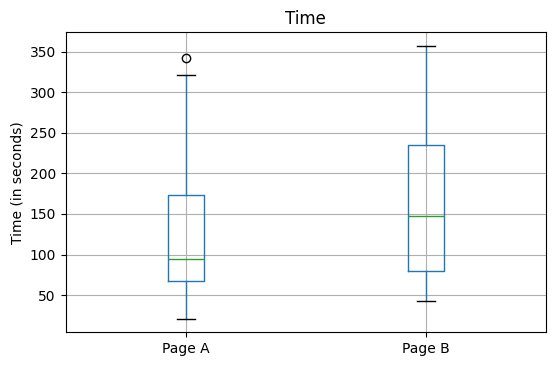

In [5]:
ax = session_times.boxplot(
    by="Page",
    column="Time",
    figsize=(6, 4)
)

ax.set_xlabel("")
ax.set_ylabel("Time (in seconds)")
plt.suptitle("")

plt.show()

**Interpretation:**

Page B appears to have longer session times than Page A.

However, we still need to determine whether this difference is large enough to be considered statistically significant.

In [6]:
mean_a = session_times[
    session_times["Page"] == "Page A"
]["Time"].mean()

mean_b = session_times[
    session_times["Page"] == "Page B"
]["Time"].mean()

print("Mean Page A:", mean_a)
print("Mean Page B:", mean_b)
print("Difference:", mean_b - mean_a)

Mean Page A: 126.33333333333333
Mean Page B: 162.0
Difference: 35.66666666666667


**Interpretation:**

Page B has an average session time about 35.67 seconds longer than Page A.

A permutation test can be used to check whether this difference could occur by random chance.

In [7]:
def perm_fun(x, nA, nB):
    n = nA + nB

    idx_B = set(random.sample(range(n), nB))
    idx_A = set(range(n)) - idx_B

    return x.iloc[list(idx_B)].mean() - x.iloc[list(idx_A)].mean()

In [8]:
nA = 21
nB = 15

perm_diffs = [
    perm_fun(session_times["Time"], nA, nB)
    for _ in range(1000)
]

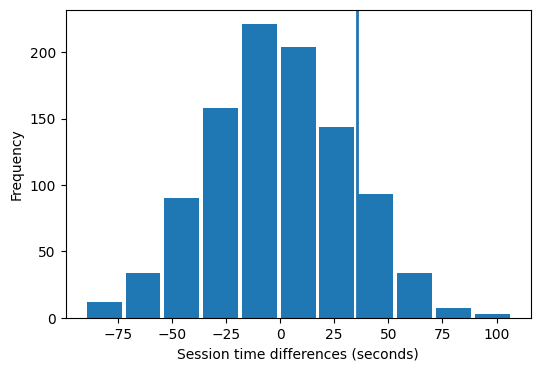

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(
    perm_diffs,
    bins=11,
    rwidth=0.9
)

ax.axvline(
    x=mean_b - mean_a,
    linewidth=2
)

ax.set_xlabel("Session time differences (seconds)")
ax.set_ylabel("Frequency")

plt.show()

In [10]:
p_value = np.mean(
    np.array(perm_diffs) > (mean_b - mean_a)
)

p_value

np.float64(0.131)

**Interpretation:**

The permutation test shows how often a difference as large as the observed difference can occur by chance.

The result suggests that the observed difference between Page A and Page B is still within the range of random variation.

## 6. t-Test

A t-test is commonly used to compare the means of two groups.

It uses the t-distribution to determine whether the observed difference between the groups is likely to occur by chance.

In [11]:
res = stats.ttest_ind(
    session_times[
        session_times["Page"] == "Page A"
    ]["Time"],
    session_times[
        session_times["Page"] == "Page B"
    ]["Time"],
    equal_var=False
)

print(
    f"p-value for single sided test: {res.pvalue / 2:.4f}"
)

p-value for single sided test: 0.1408


**Interpretation:**

The p-value is around 0.14.

This result does not provide strong evidence that Page B has a significantly higher average session time than Page A.

## 7. Statistical Significance and p-Values

Statistical significance is used to determine whether an observed result is unlikely to happen only because of random chance.

A p-value represents the probability of obtaining a result as extreme as the observed result, assuming the null hypothesis is true.

Alpha is a threshold that is commonly used to decide whether a result is statistically significant.

### 7.1 Type 1 and Type 2 Errors

A Type 1 error happens when we conclude that an effect is real even though it is actually caused by chance.

A Type 2 error happens when we conclude that an effect is not real even though a real effect exists.

## 8. Multiple Testing

Multiple testing occurs when many statistical tests are performed on the same data.

As the number of tests increases, the probability of finding a significant result only by chance also increases.

This is why multiple comparisons should be interpreted carefully.

## 9. Degrees of Freedom

Degrees of freedom represent the number of values that are free to vary when calculating a statistic.

Degrees of freedom are used in statistical distributions such as the t-distribution and F-distribution.

In [12]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

## 10. ANOVA

Analysis of Variance (ANOVA) is used to compare the means of more than two groups.

Instead of testing every pair separately, ANOVA tests whether the overall variation between group means is larger than what could be expected from random variation.

In [13]:
four_sessions = pd.DataFrame({
    "Page": (
        ["Page 1"] * 5 +
        ["Page 2"] * 5 +
        ["Page 3"] * 5 +
        ["Page 4"] * 5
    ),
    "Time": [
        164, 172, 177, 156, 195,
        178, 191, 182, 185, 177,
        175, 193, 171, 163, 176,
        155, 166, 164, 170, 168
    ]
})

four_sessions.head()

,Page,Time
0,Page 1,164
1,Page 1,172
2,Page 1,177
3,Page 1,156
4,Page 1,195


In [14]:
model = smf.ols(
    "Time ~ Page",
    data=four_sessions
).fit()

aov_table = sm.stats.anova_lm(model)

aov_table

,df,sum_sq,mean_sq,F,PR(>F)
Page,3.0,831.4,277.133333,2.739825,0.077586
Residual,16.0,1618.4,101.150000,NaN,NaN


**Interpretation:**

The ANOVA p-value is greater than 0.05.

This means the differences between the four page means are not strong enough to be considered statistically significant at the 5% level.

## 11. Chi-Square Test

The chi-square test is commonly used with categorical count data.

It compares observed counts with the counts that would be expected under the null hypothesis.

In [15]:
clicks = pd.DataFrame(
    [
        [14, 8, 12],
        [986, 992, 988]
    ],
    index=["Click", "No-click"],
    columns=["Headline A", "Headline B", "Headline C"]
)

clicks

,Headline A,Headline B,Headline C
Click,14,8,12
No-click,986,992,988


In [16]:
chisq, pvalue, df, expected = stats.chi2_contingency(clicks)

print("Chi-square:", chisq)
print("p-value:", pvalue)
print("Degrees of freedom:", df)

Chi-square: 1.6659394708658917
p-value: 0.4347562562343731
Degrees of freedom: 2


**Interpretation:**

The p-value is relatively large.

This suggests that the differences in click counts between the three headlines could reasonably occur because of random variation.

## 12. Multi-Arm Bandit Algorithm

A multi-arm bandit is an alternative approach to traditional A/B testing.

Instead of assigning equal traffic to every treatment during the entire experiment, the algorithm can gradually give more traffic to treatments that perform better.

This creates a balance between exploration and exploitation.

### Epsilon-Greedy

The epsilon-greedy algorithm sometimes chooses a treatment randomly to continue exploring alternatives.

Most of the time, it chooses the treatment that currently has the highest response rate.

## 13. Power and Sample Size

Power is the probability that a statistical test successfully detects a real effect.

The required sample size depends on the effect size, significance level, and desired statistical power.

Smaller effects usually require larger sample sizes.

In [17]:
effect_size = sm.stats.proportion_effectsize(
    0.0121,
    0.011
)

analysis = sm.stats.TTestIndPower()

result = analysis.solve_power(
    effect_size=effect_size,
    alpha=0.05,
    power=0.8,
    alternative="larger"
)

print("Sample Size: %.3f" % result)

Sample Size: 116602.391


**Interpretation:**

A relatively large sample is required because the difference between the two proportions is very small.

Smaller effect sizes are more difficult to detect and therefore require more observations.

## 14. Chapter Summary

In this chapter, I learned how statistical experiments can be used to compare different treatments.

The chapter covered A/B testing, hypothesis testing, permutation tests, p-values, t-tests, ANOVA, chi-square tests, and statistical power.

I also learned that statistical significance does not automatically mean that a result is practically important.

Resampling methods are useful for understanding whether an observed difference could happen because of random variation.